# Chess cheating detection via persistent homology
## A simplified TDA pipeline using logistic regression

**Dataset:** Lichess middlegame CPL sequences (moves 11–30), 5,000 games, 458 players  
**Unit of analysis:** Player (aggregated across games)  
**TDA features:** Shannon entropy, Wasserstein distance, bottleneck distance, Betti numbers  
**Classifier:** Logistic regression with L2 regularisation

### Pipeline overview

```
Raw CPL sequences (20 moves per game)
    │
    ├─► Persistent homology on each game's CPL sequence
    │       (path graph, sweeping CPL threshold downward)
    │       → per-game persistence diagram (birth-death pairs)
    │
    ├─► Shannon entropy of each diagram
    │
    ├─► Pairwise Wasserstein distances between a player's game diagrams
    │       → how topologically consistent is their play?
    │
    ├─► Pairwise Bottleneck distances between a player's game diagrams
    │       → robust version of Wasserstein (as in Monkam et al.)
    │
    └─► Vietoris-Rips persistent homology on the player's game cloud
            (each game = one point in R^20)
            → Betti-0 and Betti-1 features
            → cloud diameter (geometric consistency)
```

---

## 1. Imports

In [99]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from scipy.stats import mannwhitneyu
from scipy.spatial.distance import pdist

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, ConfusionMatrixDisplay

from ripser import ripser
from persim import wasserstein, bottleneck

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)
HUMAN_COL = '#3B8BD4'
CHEAT_COL = '#D85A30'
print("Imports OK.")


Imports OK.


## 2. Load data

We filter to players with at least 5 games to ensure reliable
topological features. Labels are player-level and perfectly consistent —
no player has both cheating=0 and cheating=1 games.

In [100]:
df = pd.read_csv('cpl_matrix.csv')
CPL_COLS = [c for c in df.columns if c.startswith('cpl_')]
X_raw = df[CPL_COLS].values.astype(float)
y_game = df['cheating'].values

games_per_player = df.groupby('username').size()
MIN_GAMES = 5
valid_players = games_per_player[games_per_player >= MIN_GAMES].index
df_valid = df[df['username'].isin(valid_players)].copy()

print(f"Dataset: {len(df)} games, {df['username'].nunique()} players")
print(f"Players with >= {MIN_GAMES} games: {len(valid_players)}")
print(f"Class balance (games): {y_game.mean():.1%} cheaters")
print(f"\nLabel consistency per player:")
print(df.groupby('username')['cheating'].nunique().value_counts()
        .rename({1: 'consistent', 2: 'mixed'}))


Dataset: 5000 games, 458 players
Players with >= 5 games: 394
Class balance (games): 50.0% cheaters

Label consistency per player:
cheating
consistent    458
Name: count, dtype: int64


## 3. TDA functions

### Persistent homology on CPL sequences

Each game's CPL sequence is treated as a function on a path graph
(nodes = moves, edges = consecutive move pairs). We compute the
persistent homology by sweeping a threshold downward from the maximum
CPL value — an approach equivalent to sublevel set persistence of the
negated CPL sequence.

At each threshold ε, moves with CPL ≥ ε are active. Connected runs
of active moves form components. A component is born when its local
peak (blunder) enters the filtration and dies when it merges with a
neighbouring component. The lifetime (birth − death) measures how
isolated that blunder was from surrounding bad play.

### Bottleneck distance

Following Monkam et al., we also compute the bottleneck distance
between pairs of persistence diagrams. Where Wasserstein sums all
pairwise transport costs, bottleneck takes the maximum — making it
more robust to a single anomalous feature in one game.

### Shannon entropy

Measures how spread out the feature lifetimes are within a diagram.
Low entropy = one dominant feature or all features near the diagonal.
High entropy = many features at diverse scales.

In [101]:
def preprocess_cpl(X, cap=500):
    """Clip CPL at cap centipawns to remove extreme outliers."""
    return np.clip(X, 0, cap).astype(float)


def compute_persistence_diagram(f):
    """
    Persistent homology of a CPL sequence on its path graph.

    Sweeps threshold downward from maximum CPL. Moves with CPL >= threshold
    are active; connected runs form components. A component is born at
    the CPL of its local peak and dies when it merges with a neighbour.

    Returns
    -------
    dgm : np.ndarray, shape (n_pairs, 2)
        Standard convention: column 0 = birth, column 1 = death.
        Since we sweep downward, birth > death.
        Lifetime = dgm[:, 0] - dgm[:, 1].

    dgm_std : np.ndarray, shape (n_pairs, 2)
        persim convention: column 0 = death (smaller), column 1 = birth (larger).
        Use this when passing to persim.wasserstein or persim.bottleneck.
    """
    f = np.asarray(f, dtype=float)
    n = len(f)
    if n == 0:
        return np.empty((0, 2)), np.empty((0, 2))

    edges = sorted(
        ((min(f[i], f[i + 1]), i, i + 1) for i in range(n - 1)),
        reverse=True
    )

    parent = list(range(n))
    birth_time = f.copy()

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    pairs = []
    for edge_val, u, v in edges:
        ru, rv = find(u), find(v)
        if ru != rv:
            if birth_time[ru] <= birth_time[rv]:
                pairs.append((birth_time[ru], edge_val))
                parent[ru] = rv
            else:
                pairs.append((birth_time[rv], edge_val))
                parent[rv] = ru

    if not pairs:
        return np.empty((0, 2)), np.empty((0, 2))

    dgm = np.array(pairs)              # (birth, death), birth > death
    dgm_std = dgm[:, ::-1].copy()     # (death, birth) — persim convention
    return dgm, dgm_std


def shannon_entropy(dgm):
    """
    Shannon entropy of persistence lifetimes.

    Low entropy = one dominant feature or all features near diagonal.
    High entropy = many features at comparable scales.
    """
    if len(dgm) == 0:
        return 0.
    L = dgm[:, 0] - dgm[:, 1]
    L = L[L > 0.1]
    if len(L) == 0 or L.sum() == 0:
        return 0.
    p = L / L.sum()
    return float(-np.sum(p * np.log2(p + 1e-15)))


def safe_wasserstein(dgm_std1, dgm_std2):
    """
    Wasserstein distance between two persistence diagrams.

    Accepts diagrams in persim convention: (death, birth) with death < birth.
    """
    d1 = dgm_std1 if len(dgm_std1) > 0 else np.array([[0., 0.]])
    d2 = dgm_std2 if len(dgm_std2) > 0 else np.array([[0., 0.]])
    try:
        return float(wasserstein(d1, d2))
    except Exception:
        return 0.


def safe_bottleneck(dgm_std1, dgm_std2):
    """
    Bottleneck distance between two persistence diagrams.

    Measures the largest matched gap between any pair of features.
    More robust to outliers than Wasserstein — as used in Monkam et al.
    Accepts diagrams in persim convention: (death, birth) with death < birth.
    """
    d1 = dgm_std1 if len(dgm_std1) > 0 else np.array([[0., 0.]])
    d2 = dgm_std2 if len(dgm_std2) > 0 else np.array([[0., 0.]])
    try:
        return float(bottleneck(d1, d2))
    except Exception:
        return 0.


def compute_betti_curve(dgm0_fin, thresholds):
    """
    Betti-0 curve from VR H0 persistence diagram.

    In VR filtration, H0 components are born at epsilon=0 and die
    when they merge at some epsilon. A component is still alive at
    threshold t if its death value > t (not yet merged).

    dgm0_fin : finite H0 pairs from ripser, shape (k, 2)
               column 0 = birth (always ~0 in VR)
               column 1 = death (merge distance)
    """
    if len(dgm0_fin) == 0:
        return np.zeros(len(thresholds))
    return np.array([
        np.sum(dgm0_fin[:, 1] > t)
        for t in thresholds
    ], dtype=float)


print("TDA functions defined.")


TDA functions defined.


## 4. Compute per-game persistence diagrams

In [102]:
import time

X_proc = preprocess_cpl(X_raw)
print("Computing per-game persistence diagrams...")
t0 = time.time()

# Store both formats:
# game_dgms     — (birth, death) with birth > death  — for entropy, lifetime stats
# game_dgms_std — (death, birth) with death < birth  — for persim wasserstein/bottleneck
game_dgms     = []
game_dgms_std = []
for i in range(len(X_proc)):
    dgm, dgm_std = compute_persistence_diagram(X_proc[i])
    game_dgms.append(dgm)
    game_dgms_std.append(dgm_std)

print(f"Done in {time.time()-t0:.0f}s — {len(game_dgms)} diagrams computed.")

# Sanity checks
violations = sum(
    1 for dgm in game_dgms
    if len(dgm) > 0 and np.any(dgm[:, 0] < dgm[:, 1])
)
print(f"Points below diagonal in native format (should be 0): {violations}")

all_lifetimes = np.concatenate([
    (d[:, 0] - d[:, 1]) for d in game_dgms if len(d) > 0
])
print(f"\nLifetime summary across all games:")
print(f"  Mean:             {all_lifetimes.mean():.1f} cp")
print(f"  Median:           {np.median(all_lifetimes):.1f} cp")
print(f"  Max:              {all_lifetimes.max():.1f} cp")
print(f"  Fraction > 50 cp: {np.mean(all_lifetimes > 50):.1%}")


Computing per-game persistence diagrams...
Done in 0s — 5000 diagrams computed.
Points below diagonal in native format (should be 0): 0

Lifetime summary across all games:
  Mean:             18.2 cp
  Median:           0.0 cp
  Max:              500.0 cp
  Fraction > 50 cp: 11.9%


## 5. Player-level feature extraction

For each player we compute four groups of features:

| Group | Features | What it measures |
|-------|----------|-----------------|
| Shannon entropy | mean, std across games | Diagram complexity per game |
| Wasserstein | mean, std, max pairwise | Topological consistency of play |
| Bottleneck | mean, std, max pairwise | Robust topological consistency |
| Betti numbers | H0 curve + H1 loops from VR | Shape of game cloud in ℝ²⁰ |

The Wasserstein and bottleneck features are the key novelty: they measure
how topologically similar a player's games are to each other.
Engine-assisted games are topologically interchangeable (low distances);
human games vary (high distances).

In [103]:
BETTI_THRESHOLDS = np.array([10, 25, 50, 75, 100, 150, 200], dtype=float)


def cloud_h0_entropy(dgm0_fin):
    """Shannon entropy of VR H0 lifetimes in the game cloud."""
    if len(dgm0_fin) == 0:
        return 0.
    L = dgm0_fin[:, 1] - dgm0_fin[:, 0]
    L = L[L > 1e-8]
    if len(L) == 0 or L.sum() == 0:
        return 0.
    p = L / L.sum()
    return float(-np.sum(p * np.log2(p + 1e-15)))


def bootstrap_wass_dist(player_dgms_std, ref_dgms_std, n_boot=20, rng=None):
    """
    Mean Wasserstein distance from a player's game diagrams to a class reference.

    Bootstraps by repeatedly sampling one reference game diagram and computing
    the mean Wasserstein distance from each of the player's diagrams to it.
    This keeps diagram sizes comparable (one player game vs one reference game),
    avoiding the size-asymmetry problem of pooled reference diagrams.

    Parameters
    ----------
    player_dgms_std : list of diagrams in persim convention (death, birth)
    ref_dgms_std    : list of all reference class diagrams
    """
    if rng is None:
        rng = np.random.default_rng(SEED)
    dists = []
    for _ in range(n_boot):
        ref = ref_dgms_std[rng.integers(len(ref_dgms_std))]
        d   = np.mean([safe_wasserstein(pd, ref) for pd in player_dgms_std])
        dists.append(d)
    return float(np.mean(dists))


# Build per-class reference pools (all game diagrams in persim convention)
human_ref_dgms = [game_dgms_std[i] for i in df.index[df['cheating'] == 0]]
cheat_ref_dgms = [game_dgms_std[i] for i in df.index[df['cheating'] == 1]]
print(f"Reference pools — Human: {len(human_ref_dgms)}, Cheater: {len(cheat_ref_dgms)}")


def extract_player_features(username, grp, game_dgms_list, game_dgms_std_list):
    """
    Extract TDA features for one player.

    Feature groups:
      Wasserstein distances  : wass_mean, wass_std (pairwise between games)
      Bottleneck distances   : bottleneck_mean (pairwise between games)
      Cloud H0 (VR)          : total, entropy, max_life, Betti-0 curve
      Betti-1 (VR)           : n_loops, max_life
      Reference distances    : wass_dist_to_human, wass_dist_to_cheat
                               (mean Wasserstein to bootstrapped class reference)

    Note: entropy_mean (per-game Shannon entropy) removed — not significant
    (p=0.394) and adds noise.
    """
    idxs   = list(grp.index)
    dgms   = [game_dgms_list[i]     for i in idxs]
    dgms_s = [game_dgms_std_list[i] for i in idxs]
    n      = len(idxs)
    feats  = {}

    # ── Pairwise Wasserstein — mean and std ───────────────────────────────────
    if n >= 2:
        wass_dists = np.array([
            safe_wasserstein(dgms_s[i], dgms_s[j])
            for i, j in combinations(range(n), 2)
        ])
        feats['wass_mean'] = float(wass_dists.mean())
        feats['wass_std']  = float(wass_dists.std())
    else:
        feats['wass_mean'] = 0.
        feats['wass_std']  = 0.

    # ── Pairwise Bottleneck ───────────────────────────────────────────────────
    if n >= 2:
        bn_dists = np.array([
            safe_bottleneck(dgms_s[i], dgms_s[j])
            for i, j in combinations(range(n), 2)
        ])
        feats['bottleneck_mean'] = float(bn_dists.mean())
    else:
        feats['bottleneck_mean'] = 0.

    # ── VR persistent homology on game cloud in R^20 ──────────────────────────
    pts      = preprocess_cpl(X_raw[idxs]).astype(float)
    vr       = ripser(pts, maxdim=1)
    dgm0     = vr['dgms'][0]
    dgm1     = vr['dgms'][1]
    dgm0_fin = dgm0[~np.isinf(dgm0[:, 1])]

    L0   = (dgm0_fin[:, 1] - dgm0_fin[:, 0]) if len(dgm0_fin) > 0 else np.zeros(1)
    L0_p = L0[L0 > 1e-8]

    feats['cloud_h0_total']   = float(L0_p.sum())
    feats['cloud_h0_entropy'] = cloud_h0_entropy(dgm0_fin)
    feats['cloud_h0_max_life']= float(L0_p.max()) if len(L0_p) else 0.

    bc = np.array([np.sum(dgm0_fin[:, 1] > t) for t in BETTI_THRESHOLDS], dtype=float)
    for t, b in zip(BETTI_THRESHOLDS, bc):
        feats[f'betti0_at_{int(t)}cp'] = b

    L1   = (dgm1[:, 1] - dgm1[:, 0]) if len(dgm1) > 0 else np.zeros(1)
    L1_p = L1[L1 > 1e-8]
    feats['betti1_n_loops']  = float(len(dgm1))
    feats['betti1_max_life'] = float(L1_p.max()) if len(L1_p) else 0.

    # ── Wasserstein distance to class references (bootstrap) ──────────────────
    rng = np.random.default_rng(SEED)
    feats['wass_dist_to_human'] = bootstrap_wass_dist(dgms_s, human_ref_dgms, rng=rng)
    feats['wass_dist_to_cheat'] = bootstrap_wass_dist(dgms_s, cheat_ref_dgms, rng=rng)

    feats['username'] = username
    feats['cheating'] = grp['cheating'].iloc[0]
    feats['n_games']  = float(n)
    return feats


print("Extracting player-level TDA features...")
t0 = time.time()

player_records = []
for username, grp in df_valid.groupby('username'):
    player_records.append(
        extract_player_features(username, grp, game_dgms, game_dgms_std)
    )

df_players = pd.DataFrame(player_records)
print(f"Done in {time.time()-t0:.0f}s. Shape: {df_players.shape}")

TDA_COLS = [c for c in df_players.columns
            if c not in ('username', 'cheating', 'n_games')]

print(f"\nTDA features ({len(TDA_COLS)} total):")
for c in TDA_COLS:
    print(f"  {c}")

print(f"\nSanity checks:")
print(f"  wass_mean min:            {df_players['wass_mean'].min():.3f}  (>= 0)")
print(f"  wass_std min:             {df_players['wass_std'].min():.3f}  (>= 0)")
print(f"  bottleneck_mean min:      {df_players['bottleneck_mean'].min():.3f}  (>= 0)")
print(f"  cloud_h0_total min:       {df_players['cloud_h0_total'].min():.3f}  (>= 0)")
print(f"  wass_dist_to_human min:   {df_players['wass_dist_to_human'].min():.3f}  (>= 0)")
print(f"  wass_dist_to_cheat min:   {df_players['wass_dist_to_cheat'].min():.3f}  (>= 0)")


Reference pools — Human: 2500, Cheater: 2500
Extracting player-level TDA features...
Done in 234s. Shape: (394, 20)

TDA features (17 total):
  wass_mean
  wass_std
  bottleneck_mean
  cloud_h0_total
  cloud_h0_entropy
  cloud_h0_max_life
  betti0_at_10cp
  betti0_at_25cp
  betti0_at_50cp
  betti0_at_75cp
  betti0_at_100cp
  betti0_at_150cp
  betti0_at_200cp
  betti1_n_loops
  betti1_max_life
  wass_dist_to_human
  wass_dist_to_cheat

Sanity checks:
  wass_mean min:            37.065  (>= 0)
  wass_std min:             15.242  (>= 0)
  bottleneck_mean min:      13.889  (>= 0)
  cloud_h0_total min:       372.197  (>= 0)
  wass_dist_to_human min:   167.166  (>= 0)
  wass_dist_to_cheat min:   160.702  (>= 0)


## 6. Exploratory analysis

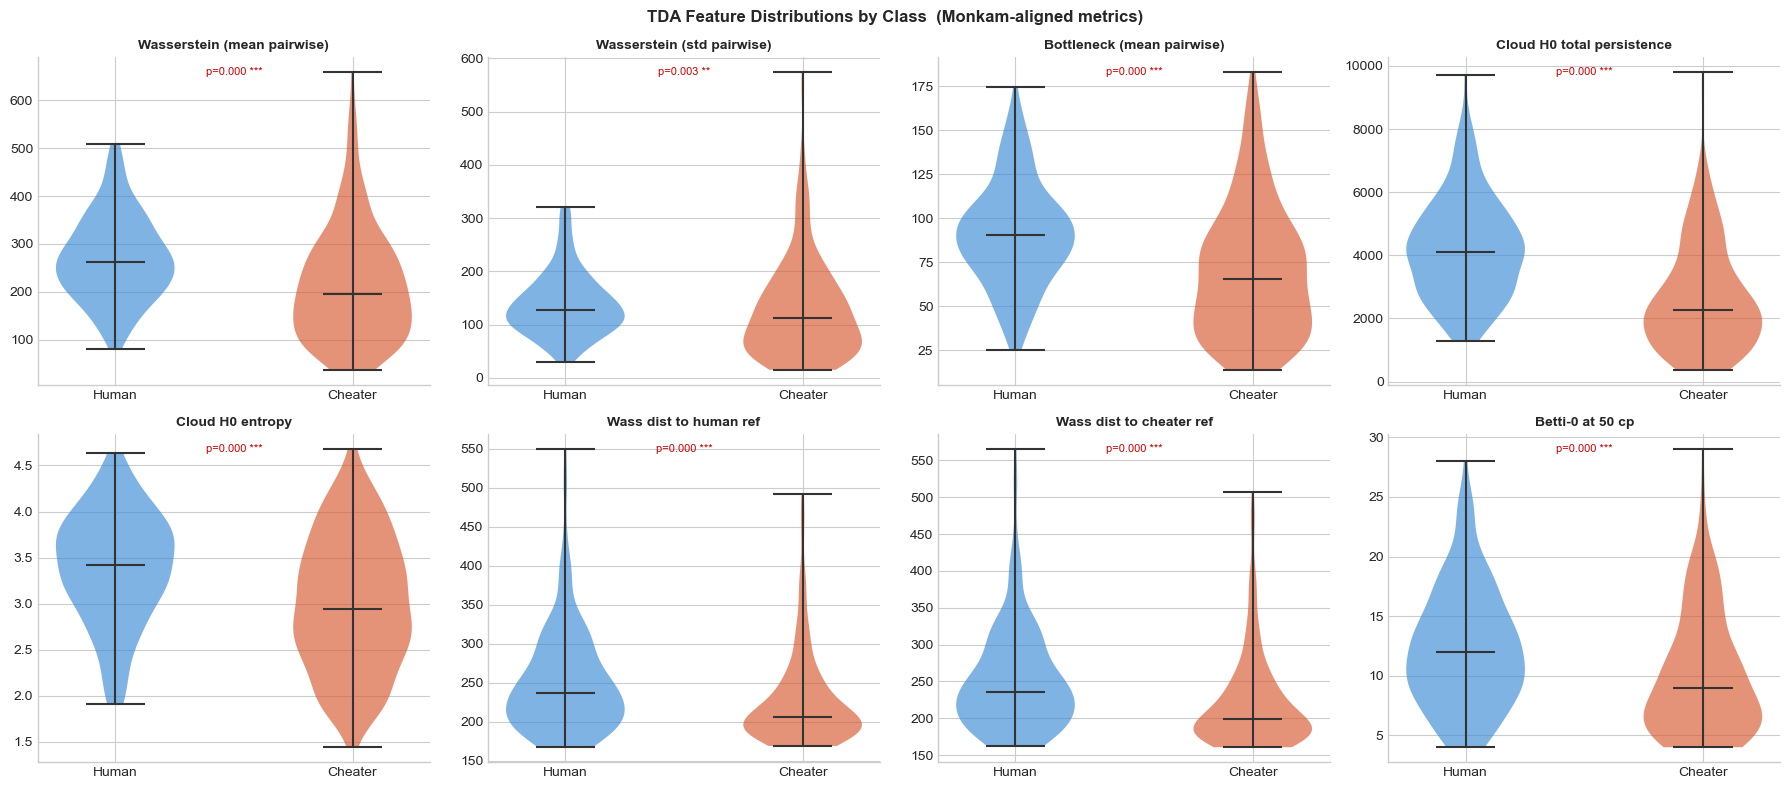

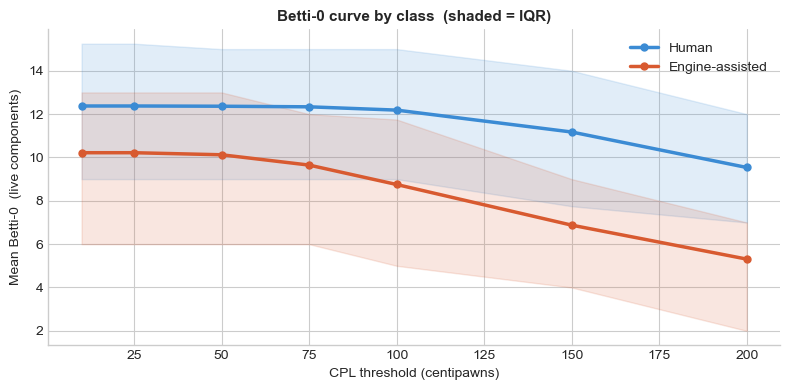


Median comparison (Mann-Whitney U test):
  Wasserstein (mean pairwise)          Human=262.52  Cheater=196.33  p=0.0000*
  Wasserstein (std pairwise)           Human=126.88  Cheater=113.10  p=0.0027*
  Bottleneck (mean pairwise)           Human=90.37  Cheater=65.69  p=0.0000*
  Cloud H0 total persistence           Human=4088.04  Cheater=2273.36  p=0.0000*
  Cloud H0 entropy                     Human=3.41  Cheater=2.94  p=0.0000*
  Wass dist to human ref               Human=236.11  Cheater=205.40  p=0.0000*
  Wass dist to cheater ref             Human=236.16  Cheater=198.43  p=0.0000*
  Betti-0 at 50 cp                     Human=12.00  Cheater=9.00  p=0.0000*


In [104]:
y_player = df_players['cheating'].values

key_feats = [
    ('wass_mean',            'Wasserstein (mean pairwise)'),
    ('wass_std',             'Wasserstein (std pairwise)'),
    ('bottleneck_mean',      'Bottleneck (mean pairwise)'),
    ('cloud_h0_total',       'Cloud H0 total persistence'),
    ('cloud_h0_entropy',     'Cloud H0 entropy'),
    ('wass_dist_to_human',   'Wass dist to human ref'),
    ('wass_dist_to_cheat',   'Wass dist to cheater ref'),
    ('betti0_at_50cp',       'Betti-0 at 50 cp'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, (feat, label) in zip(axes.flatten(), key_feats):
    h = df_players.loc[y_player == 0, feat]
    c = df_players.loc[y_player == 1, feat]
    parts = ax.violinplot([h, c], positions=[0, 1], showmedians=True)
    for pc, col in zip(parts['bodies'], [HUMAN_COL, CHEAT_COL]):
        pc.set_facecolor(col)
        pc.set_alpha(0.65)
    for part in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        parts[part].set_color('#333')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Human', 'Cheater'])
    ax.set_title(label, fontsize=10, fontweight='bold')
    stat, pval = mannwhitneyu(h, c, alternative='two-sided')
    stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    color = '#c00' if pval < 0.05 else '#888'
    ax.text(0.5, 0.97, f'p={pval:.3f} {stars}',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=8, color=color)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('TDA Feature Distributions by Class  (Monkam-aligned metrics)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Betti-0 curve
betti_cols = [f'betti0_at_{int(t)}cp' for t in BETTI_THRESHOLDS]
fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [(0, HUMAN_COL, 'Human'), (1, CHEAT_COL, 'Engine-assisted')]:
    m    = y_player == label
    mean = df_players.loc[m, betti_cols].mean().values
    q25  = df_players.loc[m, betti_cols].quantile(0.25).values
    q75  = df_players.loc[m, betti_cols].quantile(0.75).values
    ax.plot(BETTI_THRESHOLDS, mean, color=color, label=name, lw=2.5, marker='o', ms=5)
    ax.fill_between(BETTI_THRESHOLDS, q25, q75, alpha=0.15, color=color)
ax.set_xlabel('CPL threshold (centipawns)', fontsize=10)
ax.set_ylabel('Mean Betti-0  (live components)', fontsize=10)
ax.set_title('Betti-0 curve by class  (shaded = IQR)', fontsize=11, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("\nMedian comparison (Mann-Whitney U test):")
for feat, label in key_feats:
    hm = df_players.loc[y_player == 0, feat].median()
    cm = df_players.loc[y_player == 1, feat].median()
    _, pval = mannwhitneyu(
        df_players.loc[y_player == 0, feat],
        df_players.loc[y_player == 1, feat],
        alternative='two-sided'
    )
    sig = '*' if pval < 0.05 else ''
    print(f"  {label:35s}  Human={hm:.2f}  Cheater={cm:.2f}  p={pval:.4f}{sig}")


## 7. Classification — random forest

Random forest with 200 trees. Chosen over logistic regression because:

- **Captures conjunctions**: a player with simultaneously low Wasserstein,
  low bottleneck, and high H0 total is much more suspicious than a player
  unusual on one dimension alone. Random forest finds these interactions
  naturally; logistic regression cannot.
- **Handles multicollinearity**: the Betti-0 curve features are highly
  correlated. Random forest's feature subsampling at each split prevents
  correlated features from cancelling each other out.
- **Robust with small n**: 394 players is small but random forest generalises
  well via bootstrap sampling and out-of-bag validation.

We compare three feature sets: TDA only, baseline CPL statistics only,
and the combined set.

In [105]:
from sklearn.ensemble import RandomForestClassifier

X_tda = df_players[TDA_COLS].values
y     = y_player

# ── Baseline features ─────────────────────────────────────────────────────────
baseline_rows = []
for username, grp in df_valid.groupby('username'):
    Xp = X_raw[grp.index]
    consec_low = []
    for row in Xp:
        best = cur = 0
        for v in row:
            cur = cur + 1 if v <= 10 else 0
            best = max(best, cur)
        consec_low.append(best)
    baseline_rows.append({
        'username':        username,
        'mean_cpl':        float(Xp.mean()),
        'std_cpl':         float(Xp.std()),
        'median_cpl':      float(np.median(Xp)),
        'mean_game_std':   float(Xp.std(axis=1).mean()),
        'std_game_mean':   float(Xp.mean(axis=1).std()),
        'n_blunders_mean': float((Xp > 100).mean()),
        'n_perfect_mean':  float((Xp <= 2).mean()),
        'consec_low_mean': float(np.mean(consec_low)),
    })

df_base = pd.DataFrame(baseline_rows)
df_all  = df_players.merge(df_base, on='username')

BASE_COLS = [c for c in df_base.columns if c != 'username']
ALL_COLS  = TDA_COLS + BASE_COLS

X_base = df_all[BASE_COLS].values
X_all  = df_all[ALL_COLS].values

feature_sets = {
    'TDA only':       X_tda,
    'Baseline only':  X_base,
    'TDA + Baseline': X_all,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_rf(X, y):
    pipe = Pipeline([
        ('sc', StandardScaler()),
        ('rf', RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=SEED, n_jobs=-1
        ))
    ])
    auc = cross_val_score(pipe, X, y, cv=skf, scoring='roc_auc')
    f1  = cross_val_score(pipe, X, y, cv=skf, scoring='f1')
    return auc, f1


print("5-fold CV — Random Forest:")
cv_results = {}
for name, X in feature_sets.items():
    auc, f1 = cv_rf(X, y)
    cv_results[name] = {'auc': auc, 'f1': f1}
    print(f"  {name:20s}  AUC={auc.mean():.3f} ± {auc.std():.3f}  "
          f"F1={f1.mean():.3f} ± {f1.std():.3f}")


5-fold CV — Random Forest:
  TDA only              AUC=0.767 ± 0.071  F1=0.709 ± 0.053
  Baseline only         AUC=0.769 ± 0.057  F1=0.694 ± 0.050
  TDA + Baseline        AUC=0.781 ± 0.052  F1=0.726 ± 0.044


## 8. Results

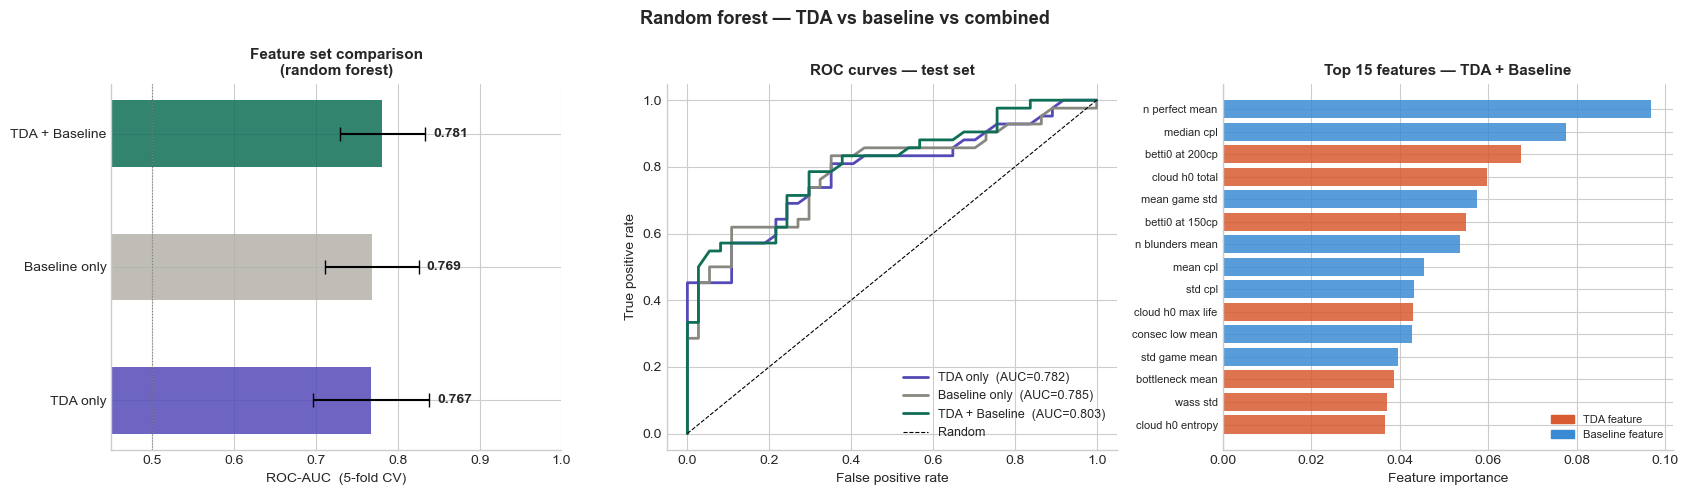


Full classification report (TDA + Baseline, test set):
              precision    recall  f1-score   support

       Human       0.67      0.76      0.71        37
     Cheater       0.76      0.67      0.71        42

    accuracy                           0.71        79
   macro avg       0.71      0.71      0.71        79
weighted avg       0.71      0.71      0.71        79

ROC-AUC: 0.8063


In [106]:
from sklearn.model_selection import train_test_split

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── AUC comparison bar chart ──────────────────────────────────────────────────
ax = axes[0]
names  = list(cv_results.keys())
aucs   = [cv_results[n]['auc'].mean() for n in names]
errs   = [cv_results[n]['auc'].std()  for n in names]
colors = ['#534AB7', '#B4B2A9', '#0F6E56']
bars   = ax.barh(names, aucs, xerr=errs, color=colors,
                  alpha=0.85, capsize=5, height=0.5)
ax.axvline(0.5, color='gray', linestyle=':', lw=0.8)
ax.set_xlabel('ROC-AUC  (5-fold CV)', fontsize=10)
ax.set_title('Feature set comparison\n(random forest)',
             fontsize=11, fontweight='bold')
ax.set_xlim(0.45, 1.0)
ax.spines[['top', 'right']].set_visible(False)
for bar, val, err in zip(bars, aucs, errs):
    ax.text(val + err + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

# ── ROC curves ────────────────────────────────────────────────────────────────
ax = axes[1]
roc_colors = {
    'TDA only':       '#534AB7',
    'Baseline only':  '#888780',
    'TDA + Baseline': '#0F6E56',
}
for name, X in feature_sets.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED
    )
    pipe = Pipeline([
        ('sc', StandardScaler()),
        ('rf', RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=SEED, n_jobs=-1
        ))
    ])
    pipe.fit(X_tr, y_tr)
    prob = pipe.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc = roc_auc_score(y_te, prob)
    ax.plot(fpr, tpr, color=roc_colors[name], lw=2,
            label=f'{name}  (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
ax.set_xlabel('False positive rate', fontsize=10)
ax.set_ylabel('True positive rate', fontsize=10)
ax.set_title('ROC curves — test set', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Feature importance for TDA + Baseline ────────────────────────────────────
ax = axes[2]
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=SEED
)
sc_f = StandardScaler()
rf_f = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
rf_f.fit(sc_f.fit_transform(X_tr), y_tr)

imp     = rf_f.feature_importances_
top_n   = min(15, len(ALL_COLS))
top_idx = np.argsort(imp)[-top_n:]
top_imp = imp[top_idx]
top_names = [ALL_COLS[i].replace('_', ' ') for i in top_idx]
bar_colors = ['#D85A30' if ALL_COLS[i] in TDA_COLS else '#3B8BD4'
              for i in top_idx]

ax.barh(range(top_n), top_imp, color=bar_colors, alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names, fontsize=8)
ax.set_xlabel('Feature importance', fontsize=10)
ax.set_title(f'Top {top_n} features — TDA + Baseline',
             fontsize=11, fontweight='bold')
tda_p  = mpatches.Patch(color='#D85A30', label='TDA feature')
base_p = mpatches.Patch(color='#3B8BD4', label='Baseline feature')
ax.legend(handles=[tda_p, base_p], fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Random forest — TDA vs baseline vs combined',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nFull classification report (TDA + Baseline, test set):")
y_pred = rf_f.predict(sc_f.transform(X_te))
print(classification_report(y_te, y_pred, target_names=['Human', 'Cheater']))
print(f"ROC-AUC: {roc_auc_score(y_te, rf_f.predict_proba(sc_f.transform(X_te))[:,1]):.4f}")


## 9. Player-level analysis

Out-of-fold probabilities give a cheating score for every player
without data leakage. The coefficient plot shows which features
the model relies on — positive coefficients push toward cheater,
negative toward human.

In [107]:
pipe_final = Pipeline([
    ('sc', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=SEED, n_jobs=-1
    ))
])
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_probs = cross_val_predict(
    pipe_final, X_all, y, cv=skf5, method='predict_proba'
)[:, 1]

df_all['cheat_prob']  = oof_probs
df_all['uncertainty'] = np.abs(oof_probs - 0.5)

print("=== Most confidently detected CHEATERS ===")
sub = df_all[df_all['cheating'] == 1].nlargest(5, 'cheat_prob')
print(sub[['username', 'cheat_prob', 'wass_mean', 'bottleneck_mean',
           'cloud_h0_total', 'wass_dist_to_human', 'n_games']].to_string(index=False))

print("\n=== Most confidently detected HUMANS ===")
sub = df_all[df_all['cheating'] == 0].nsmallest(5, 'cheat_prob')
print(sub[['username', 'cheat_prob', 'wass_mean', 'bottleneck_mean',
           'cloud_h0_total', 'wass_dist_to_human', 'n_games']].to_string(index=False))

print("\n=== Hardest cases (probability nearest 0.5) ===")
hard = df_all.nsmallest(6, 'uncertainty')
print(hard[['username', 'cheating', 'cheat_prob', 'wass_mean',
            'bottleneck_mean', 'cloud_h0_total']].to_string(index=False))


=== Most confidently detected CHEATERS ===
         username  cheat_prob  wass_mean  bottleneck_mean  cloud_h0_total  wass_dist_to_human  n_games
       amroishere         1.0  74.007648        29.119048      661.771217          195.777570      7.0
          bennhur         1.0 135.283262        31.361111     1107.996239          196.770812      9.0
christopherhirata         1.0  71.765343        20.375000      633.715134          204.157179      8.0
       cuteknight         1.0  72.278083        18.178571      548.224808          205.529982      8.0
          maiazea         1.0  56.136995        20.785714      540.213867          198.595033      7.0

=== Most confidently detected HUMANS ===
      username  cheat_prob  wass_mean  bottleneck_mean  cloud_h0_total  wass_dist_to_human  n_games
princeofpersil    0.053333 354.133482       117.969697     5062.419006          313.626108     12.0
     yesyouare    0.060000 361.876558       134.852564     5433.549500          300.731237     13

## 10. Persistence barcodes

Each horizontal bar is one topological feature. Bar length = lifetime
(birth − death in centipawns). Longer bars = more isolated blunders.

We pool 8 games near the median CPL for each class to show the
typical pattern rather than cherry-picked examples.

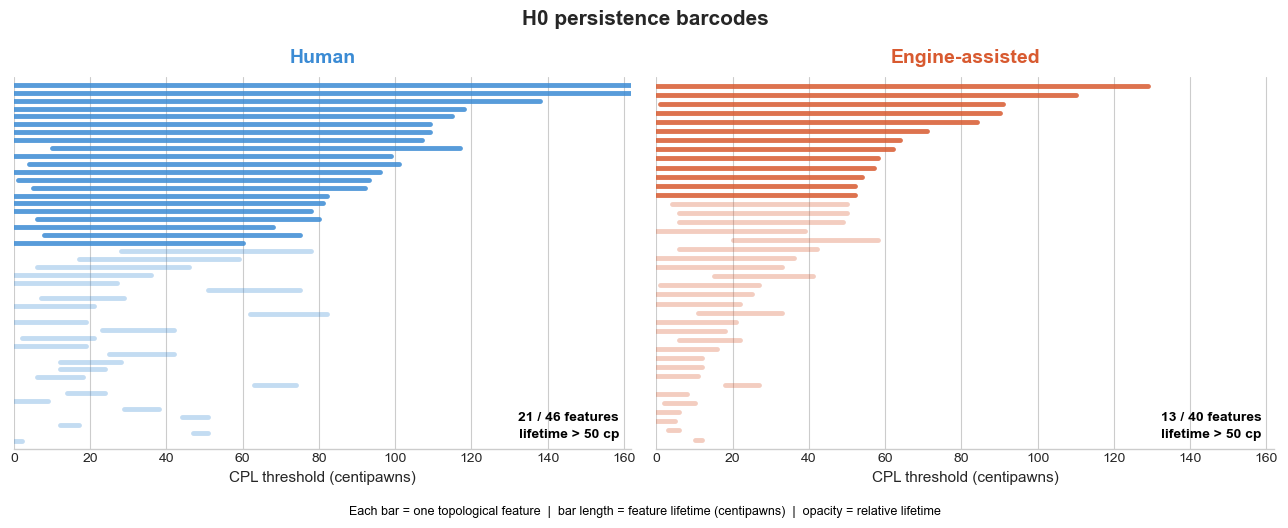

In [120]:
def get_median_games(X_raw, y_game, label, n=8):
    idx   = np.where(y_game == label)[0]
    means = X_raw[idx].mean(axis=1)
    med   = np.median(means)
    order = np.argsort(np.abs(means - med))
    return idx[order[:n]]


def pool_bars(idxs, dgms):
    pairs = [dgms[i] for i in idxs if len(dgms[i]) > 0]
    if not pairs:
        return np.empty((0, 2))
    dgm = np.vstack(pairs)
    L   = dgm[:, 0] - dgm[:, 1]
    return dgm[np.argsort(L)[::-1]]


human_idxs = get_median_games(X_raw, y_game, 0, n=8)
cheat_idxs = get_median_games(X_raw, y_game, 1, n=8)
h_bars     = pool_bars(human_idxs, game_dgms)
c_bars     = pool_bars(cheat_idxs, game_dgms)

# Only keep bars with meaningful lifetime — removes invisible zero-length bars
# that create whitespace without contributing anything visible
MIN_LIFE = 2.0   # cp — below this a bar is a dot, not a bar
h_bars   = h_bars[(h_bars[:, 0] - h_bars[:, 1]) >= MIN_LIFE]
c_bars   = c_bars[(c_bars[:, 0] - c_bars[:, 1]) >= MIN_LIFE]

xmax   = np.percentile(
    np.concatenate([h_bars[:, 0], c_bars[:, 0]]), 98
) * 1.05
THRESH = 50

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)


def plot_barcode(ax, bars, color, label):
    n = len(bars)
    for i, (birth, death) in enumerate(bars):
        lifetime = birth - death
        long     = lifetime > THRESH
        ax.plot([death, birth], [n - i, n - i],
                color=color,
                lw=3.5,
                alpha=0.85 if long else 0.30,
                solid_capstyle='round',
                zorder=3 if long else 2)

    n_long = int(np.sum(bars[:, 0] - bars[:, 1] > THRESH))

    ax.set_xlim(0, xmax)
    ax.set_ylim(0, n + 1)        # tight — n is now only visible bars
    ax.set_xlabel('CPL threshold (centipawns)', fontsize=11)
    ax.set_title(label, fontsize=14, fontweight='bold', color=color, pad=10)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(left=False)
    ax.set_yticks([])

    # Black text for poster readability
    ax.text(0.98, 0.02,
            f'{n_long} / {n} features\nlifetime > {THRESH} cp',
            transform=ax.transAxes,
            ha='right', va='bottom',
            fontsize=10, color='black',
            fontweight='bold', linespacing=1.5)


plot_barcode(axes[0], h_bars, HUMAN_COL, 'Human')
plot_barcode(axes[1], c_bars, CHEAT_COL, 'Engine-assisted')

fig.text(0.5, -0.03,
         'Each bar = one topological feature  '
         '|  bar length = feature lifetime (centipawns)  '
         '|  opacity = relative lifetime',
         ha='center', fontsize=9, color='black')

fig.suptitle('H0 persistence barcodes',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('barcodes_poster.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()


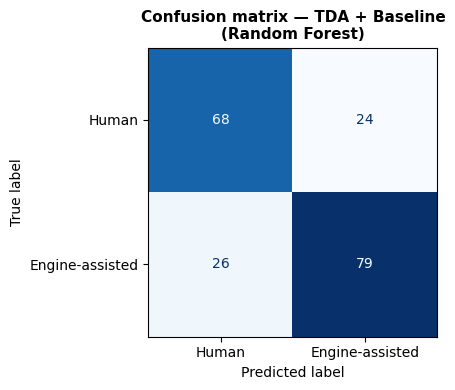

Test ROC-AUC: 0.8076
                 precision    recall  f1-score   support

          Human       0.72      0.74      0.73        92
Engine-assisted       0.77      0.75      0.76       105

       accuracy                           0.75       197
      macro avg       0.75      0.75      0.75       197
   weighted avg       0.75      0.75      0.75       197



In [114]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y, test_size=0.5, stratify=y, random_state=SEED
)
sc = StandardScaler()
rf = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
rf.fit(sc.fit_transform(X_tr), y_tr)
y_pred = rf.predict(sc.transform(X_te))

with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=['Human', 'Engine-assisted'],
        colorbar=False,
        cmap='Blues',
        ax=ax
    )
    ax.set_title('Confusion matrix — TDA + Baseline\n(Random Forest)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('confusion_matrix_poster.png', dpi=180,
                bbox_inches='tight', facecolor='white')
    plt.show()

print(f"Test ROC-AUC: {roc_auc_score(y_te, rf.predict_proba(sc.transform(X_te))[:,1]):.4f}")
print(classification_report(y_te, y_pred, target_names=['Human', 'Engine-assisted']))

## 11. Summary

### Feature interpretation

| Feature | Cheater | Human | Why |
|---------|---------|-------|-----|
| `wass_mean` | Low | High | Engine games topologically identical |
| `bottleneck_mean` | Low | High | Robust version of same signal |
| `entropy_mean` | Low | High | Human diagrams more complex |
| `betti0_max_life` | High | Lower | Cheater cloud has one tight cluster |
| `cloud_diameter` | Low | High | Human games spread in CPL space |

### Relationship to Monkam et al.

Monkam et al. apply cubical persistent homology to individual network
packet images, extracting 126 features per packet including bottleneck
amplitude, Wasserstein amplitude, Betti curves, and persistence entropy.

This pipeline applies the same conceptual tools to chess:
- Persistent homology on sequences (analogous to their per-packet diagrams)
- Bottleneck and Wasserstein distances (same metrics, different domain)
- Betti curves from VR homology on the player cloud (novel extension)

The key difference is aggregation: because chess labels are player-level,
we compute distances *between* a player's games rather than treating
each game independently.